<a href="https://colab.research.google.com/github/sayedHoosini/AI_Portfolio_ITAI2372/blob/main/fraud%20detection%20project%20using%20random%20forest%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload the file for the creditcard.csv

In [17]:
import pandas as pd

df = pd.read_csv("/content/creditcard.csv")

print("File loaded successfully")
print("Shape:", df.shape)
print(df.head())

File loaded successfully
Shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -

In [18]:
import pandas as pd

df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
print("Shape of dataset:", df.shape)

print("\nColumn names:\n", df.columns.tolist())

print("\nMissing values:\n", df.isnull().sum())

print("\nClass distribution:\n", df["Class"].value_counts())

print("\nFraud percentage:\n", df["Class"].value_counts(normalize=True) * 100)

Shape of dataset: (284807, 31)

Column names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage:
 Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


The dataset is imbalanced, with fraud transactions representing only about 0.17% of all transactions. This creates a challenge for machine learning models because a high accuracy score can still correspond to poor fraud detection performance. Therefore, evaluation metrics such as recall, precision, and F1-score are better than accuracy alone.

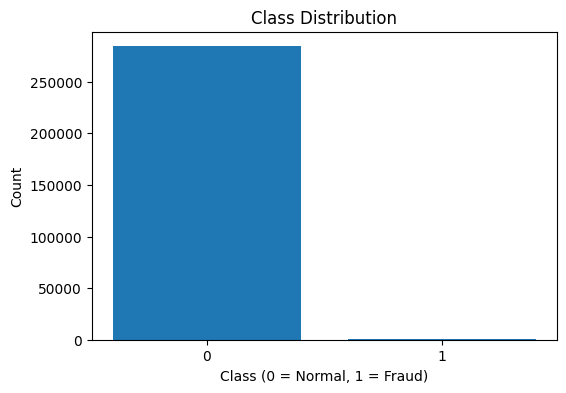

In [20]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [21]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Fraud in train:", y_train.mean())
print("Fraud in test:", y_test.mean())

Train size: (227845, 30)
Test size: (56962, 30)
Fraud in train: 0.001729245759178389
Fraud in test: 0.0017204452090867595


Building Random Forest model Baseline

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

Evaluate the model

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1 Score :", round(f1, 4))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.9996
Precision: 0.9412
Recall   : 0.8163
F1 Score : 0.8743

Confusion Matrix:
 [[56859     5]
 [   18    80]]


In [25]:
y_probs = rf_model.predict_proba(X_test)[:, 1]

In [26]:
threshold = 0.3

y_pred_new = (y_probs >= threshold).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_test, y_pred_new))
print("Recall   :", recall_score(y_test, y_pred_new))
print("F1 Score :", f1_score(y_test, y_pred_new))

Precision: 0.86
Recall   : 0.8775510204081632
F1 Score : 0.8686868686868687


In [27]:
thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    print(f"\nThreshold = {t}")
    print("Precision:", round(precision_score(y_test, preds), 4))
    print("Recall   :", round(recall_score(y_test, preds), 4))
    print("F1 Score :", round(f1_score(y_test, preds), 4))


Threshold = 0.5
Precision: 0.9412
Recall   : 0.8163
F1 Score : 0.8743

Threshold = 0.4
Precision: 0.9333
Recall   : 0.8571
F1 Score : 0.8936

Threshold = 0.3
Precision: 0.86
Recall   : 0.8776
F1 Score : 0.8687

Threshold = 0.2
Precision: 0.7963
Recall   : 0.8776
F1 Score : 0.835


In [28]:
from sklearn.metrics import confusion_matrix

for t in [0.5, 0.4, 0.3]:
    preds = (y_probs >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(confusion_matrix(y_test, preds))


Threshold = 0.5
[[56859     5]
 [   18    80]]

Threshold = 0.4
[[56858     6]
 [   14    84]]

Threshold = 0.3
[[56850    14]
 [   12    86]]


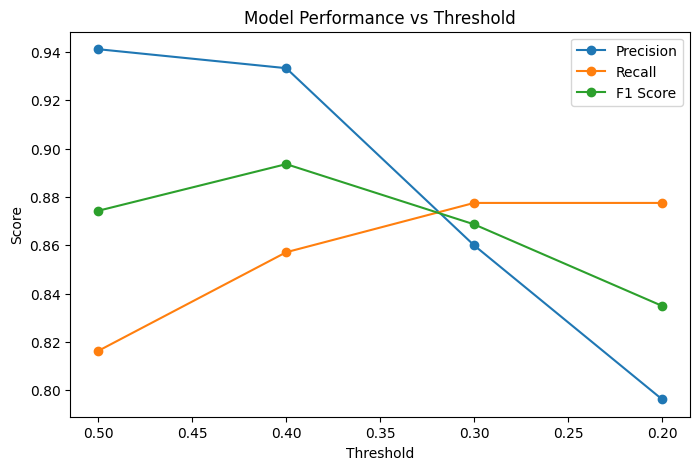

In [29]:
import matplotlib.pyplot as plt

thresholds = [0.5, 0.4, 0.3, 0.2]

precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    preds = (y_probs >= t).astype(int)

    precision_list.append(precision_score(y_test, preds))
    recall_list.append(recall_score(y_test, preds))
    f1_list.append(f1_score(y_test, preds))

plt.figure(figsize=(8,5))

plt.plot(thresholds, precision_list, marker='o', label="Precision")
plt.plot(thresholds, recall_list, marker='o', label="Recall")
plt.plot(thresholds, f1_list, marker='o', label="F1 Score")

plt.title("Model Performance vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()

plt.gca().invert_xaxis()  # higher threshold on left (looks nicer)
plt.show()

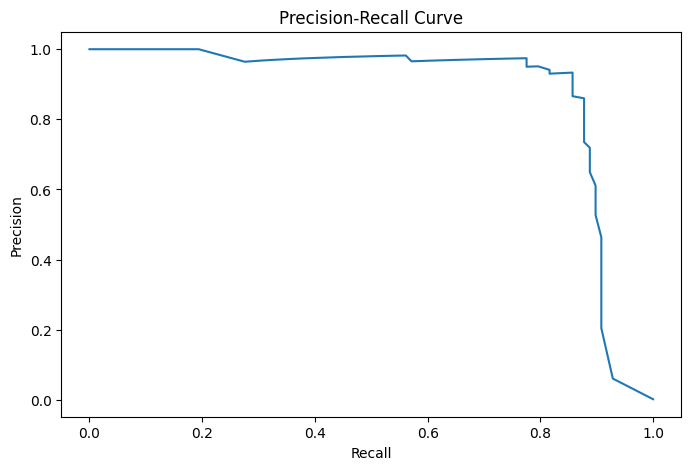

In [30]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8,5))
plt.plot(recalls, precisions)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.show()